In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
df=pd.read_csv("/content/drive/MyDrive/MLT/insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [17]:
df.isnull()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


<Axes: >

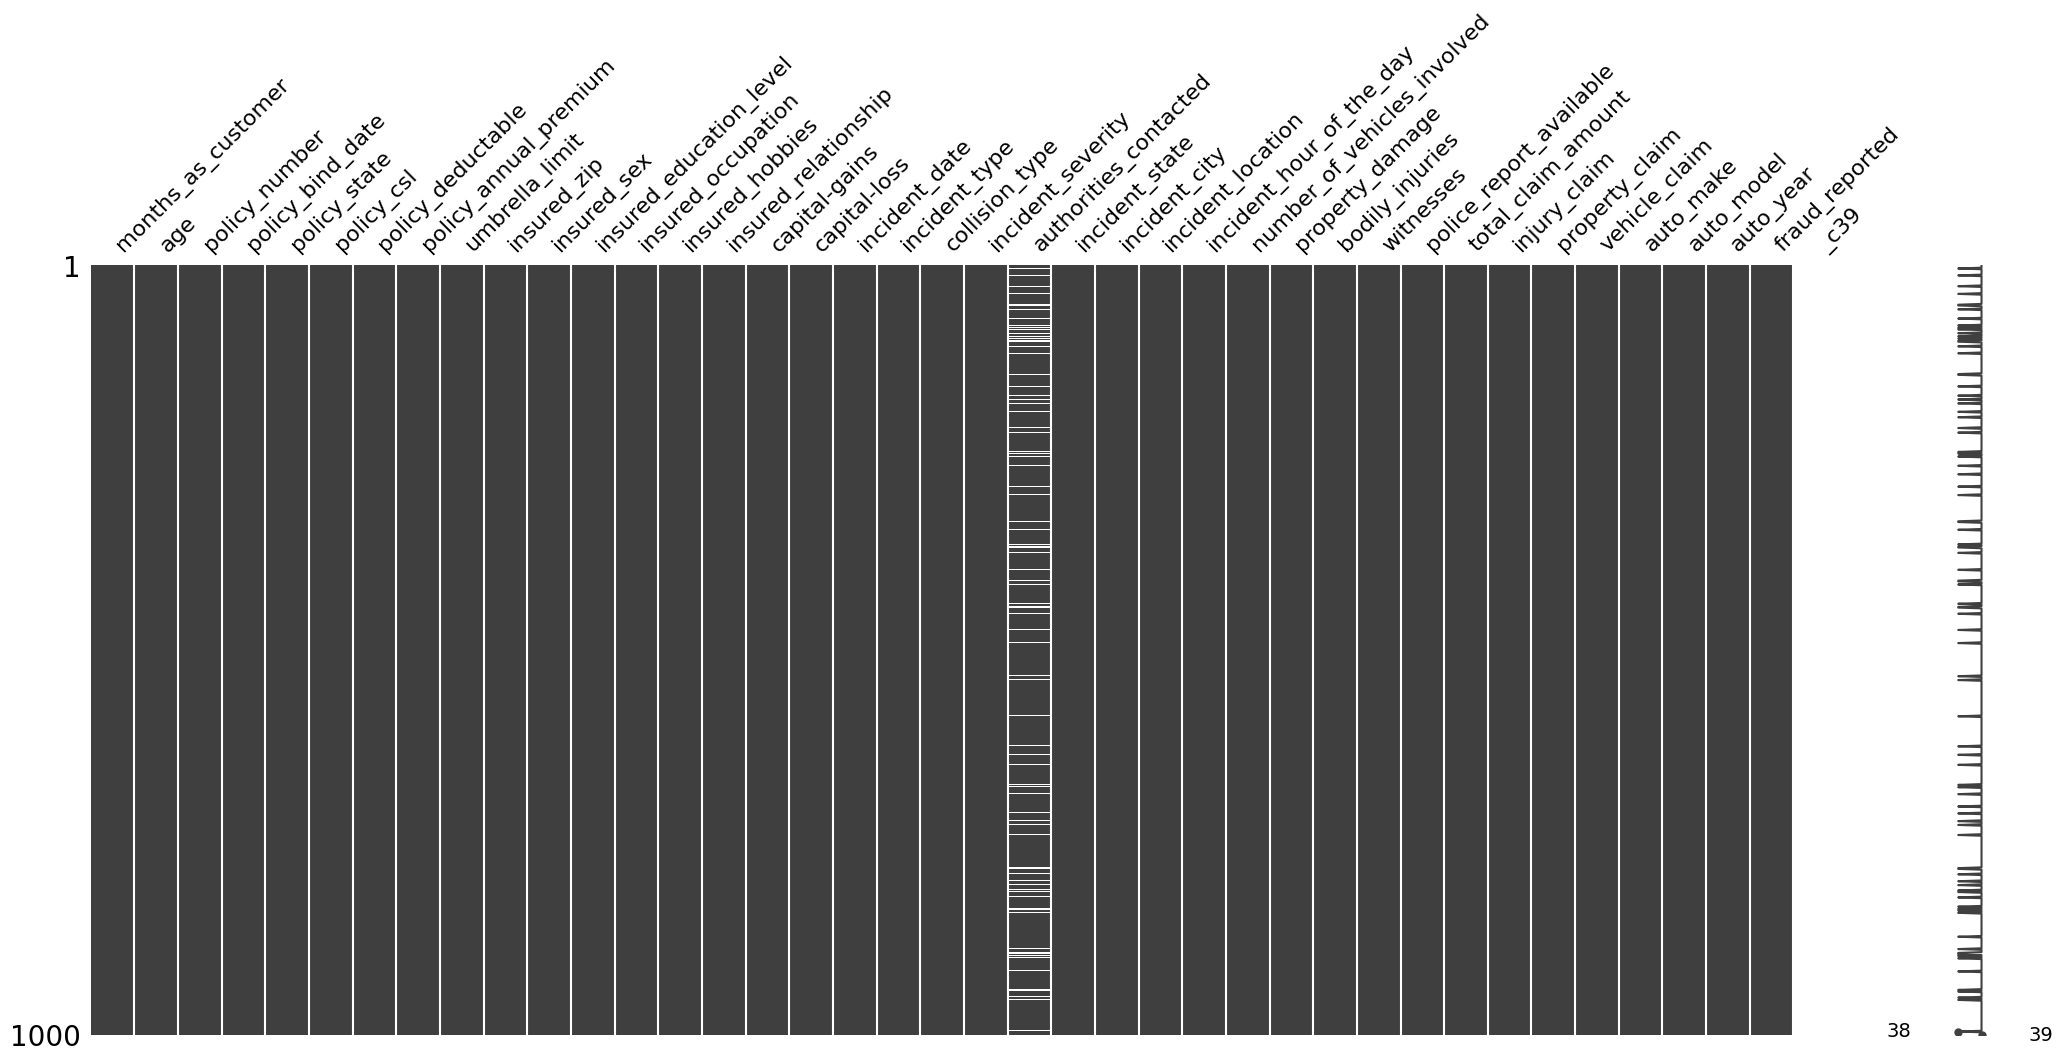

In [18]:
import missingno as msno
msno.matrix(df)

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

In [20]:
Q1 = df['total_claim_amount'].quantile(0.25)
Q3 = df['total_claim_amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[
    (df['total_claim_amount'] < lower) |
    (df['total_claim_amount'] > upper)
]
print(outliers)

    months_as_customer  age  policy_number  policy_bind_date  policy_state  \
11                 447   61         214618               370             2   

    policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
11           0               2000                1137.16               0   

    insured_zip  ...  police_report_available  total_claim_amount  \
11       615561  ...                        2              114920   

    injury_claim  property_claim  vehicle_claim  auto_make  auto_model  \
11         17680           17680          79560          1           4   

    auto_year  fraud_reported  _c39  
11       2006               0   NaN  

[1 rows x 40 columns]


In [21]:
x = df.drop('policy_bind_date', axis=1)
y = df['witnesses']

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train ,y_test= train_test_split(
    x,y, test_size=0.2 , random_state=1
)

In [23]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(
    criterion='gini',
    random_state=1
)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=1)

In [24]:
y_pred=model.predict(x_test)


In [25]:
from sklearn.metrics import accuracy_score
print("Accuracy Score",accuracy_score(y_test,y_pred))

Accuracy Score 1.0


In [26]:
from sklearn.metrics import confusion_matrix,classification_report
print("Confusion Matrix",confusion_matrix(y_test,y_pred))
print("Classification Report",classification_report(y_test,y_pred))

Confusion Matrix [[55  0  0  0]
 [ 0 64  0  0]
 [ 0  0 42  0]
 [ 0  0  0 39]]
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        64
           2       1.00      1.00      1.00        42
           3       1.00      1.00      1.00        39

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

